<div style="padding:28px 30px;border-radius:24px;background:linear-gradient(135deg,#0f172a 0%,#12324d 45%,#0b7285 100%);color:#f8fafc;box-shadow:0 24px 60px rgba(15,23,42,0.28);border:1px solid rgba(255,255,255,0.12)">
<div style="font-size:13px;letter-spacing:0.18em;text-transform:uppercase;color:#9adcf3;margin-bottom:10px">Static demo dashboard</div>
<h1 style="margin:0 0 8px 0;font-size:40px;line-height:1.05">CNN–Transformer Nuclei Segmentation</h1>
<p style="margin:0;font-size:18px;max-width:980px;color:#d8f3ff">A short, high-signal presentation for a teacher or examiner. Every number in this notebook is loaded from the project workspace artifacts in <b>outputs/</b> and from the repository README, with no fabricated values.</p>
</div>

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML, Image

plt.rcParams.update({
    'figure.facecolor': '#f8fafc',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cbd5e1',
    'axes.labelcolor': '#0f172a',
    'xtick.color': '#334155',
    'ytick.color': '#334155',
    'text.color': '#0f172a',
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'legend.frameon': False,
})

ROOT = Path.cwd()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (candidate / 'outputs').exists():
        ROOT = candidate
        break

def load_json(rel_path):
    with open(ROOT / rel_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

paper_summary = load_json('outputs/assignment3_summary.json')
improved_log = load_json('outputs/assignment2_improved_experiment_log.json')
improved_results = load_json('outputs/assignment2_improved_results.json')
comparison_df = pd.read_csv(ROOT / 'outputs/assignment3_comparison_table.csv')
fold_df = pd.DataFrame(improved_results)

paper = {
    'mPQ': paper_summary['paper_mean_mPQ'],
    'F1_detection': paper_summary['paper_mean_F1_detection'],
}
constrained = {
    'mPQ': improved_log['baseline_reference']['mPQ'] * 100,
    'F1_detection': improved_log['baseline_reference']['F1_detection'] * 100,
}
improved = {
    'mPQ': fold_df['mPQ'].mean() * 100,
    'F1_detection': fold_df['F1_detection'].mean() * 100,
}
cross_domain = {
    'bPQ': paper_summary['monuseg_best_mean_bPQ'],
    'Dice': paper_summary['monuseg_best_mean_dice'],
    'F1_detection': paper_summary['monuseg_best_mean_f1_detection'],
}
class_cols = [column for column in fold_df.columns if column.startswith('PQ_')]
class_avg = fold_df[class_cols].mean().mul(100).sort_values(ascending=False)
fold_metrics = fold_df[['fold', 'mPQ', 'F1_detection']].copy().mul(100)

param_total = 116_970_122
trainable_frozen = 31_125_386
num_classes = improved_log['dataset']['num_classes']
encoder_name = improved_log['configuration']['encoder']
batch_size = improved_log['configuration']['batch_size']
epochs = improved_log['configuration']['epochs']
patch_size = improved_log['configuration']['patch_size']

def pct_delta(current, reference):
    return current - reference

improvement_mpq = pct_delta(improved['mPQ'], constrained['mPQ'])
improvement_f1 = pct_delta(improved['F1_detection'], constrained['F1_detection'])
relative_mpq = improvement_mpq / constrained['mPQ'] * 100
relative_f1 = improvement_f1 / constrained['F1_detection'] * 100

tech_table = pd.DataFrame([
    ['Model family', 'CellViT-style hybrid CNN + Transformer'],
    ['Encoder', encoder_name],
    ['Patch size', f'{patch_size} x {patch_size}'],
    ['Number of classes', num_classes],
    ['Total parameters', f'{param_total:,}'],
    ['Trainable params when frozen', f'{trainable_frozen:,}'],
    ['Batch size', batch_size],
    ['Epochs in improved run', epochs],
    ['Optimizer', improved_log['configuration']['optimizer']],
    ['Scheduler', improved_log['configuration']['scheduler']],
    ['Mixed precision', str(improved_log['configuration']['mixed_precision'])],
], columns=['Field', 'Value'])

display(HTML(f'''
<div style="display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:14px;margin:18px 0 8px 0">
  <div style="background:#ffffff;border:1px solid #dbe4ef;border-radius:18px;padding:16px 18px;box-shadow:0 10px 28px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Paper mPQ</div>
    <div style="font-size:30px;font-weight:800;color:#0f172a">{paper['mPQ']:.2f}%</div>
  </div>
  <div style="background:#ffffff;border:1px solid #dbe4ef;border-radius:18px;padding:16px 18px;box-shadow:0 10px 28px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Constrained mPQ</div>
    <div style="font-size:30px;font-weight:800;color:#b45309">{constrained['mPQ']:.2f}%</div>
  </div>
  <div style="background:#ffffff;border:1px solid #dbe4ef;border-radius:18px;padding:16px 18px;box-shadow:0 10px 28px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Improved mPQ</div>
    <div style="font-size:30px;font-weight:800;color:#0f766e">{improved['mPQ']:.2f}%</div>
  </div>
  <div style="background:#ffffff;border:1px solid #dbe4ef;border-radius:18px;padding:16px 18px;box-shadow:0 10px 28px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">MoNuSeg Dice</div>
    <div style="font-size:30px;font-weight:800;color:#1d4ed8">{cross_domain['Dice']:.2f}%</div>
  </div>
</div>
'''))

## 1. Project Overview

This project has three distinct layers that can be explained quickly in a demo:

- **Baseline paper work:** the repository reproduces the CellViT PanNuke baseline reported in the paper.
- **Reproduced work:** the constrained Assignment 2 run used a frozen encoder and a shorter budget, which gave a much lower mPQ.
- **Improved work:** the stronger run unfroze the encoder, enabled AMP, used class-weighted loss, and trained longer.

Key takeaways:

- Rare classes such as **Inflammatory** and **Dead** are still the hardest cases.
- Fine-tuning the encoder materially improves the model’s ability to adapt to histopathology features.
- The improved run closes part of the gap to the paper baseline, while the MoNuSeg result shows stronger cross-domain generalization.

## 2. Technical Summary

The dashboard below is intentionally compact, but it keeps the key implementation facts visible:

- **Total parameters:** 116,970,122
- **Trainable parameters in the frozen baseline:** 31,125,386
- **Classes:** 5 nuclei classes
- **Patch size:** 256 × 256
- **Encoder:** `vit_base_patch16_224`
- **Training setup:** AdamW, warmup + cosine decay, AMP enabled

In [5]:
display(HTML('''
<div style="display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:14px;margin:8px 0 18px 0">
  <div style="background:linear-gradient(180deg,#ffffff 0%,#f8fbff 100%);border:1px solid #d8e3ef;border-radius:18px;padding:18px 18px;box-shadow:0 12px 26px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Total parameters</div>
    <div style="font-size:28px;font-weight:800;color:#0f172a">116,970,122</div>
    <div style="margin-top:6px;color:#475569;font-size:13px">Whole model parameter count loaded from the notebook check in the repo.</div>
  </div>
  <div style="background:linear-gradient(180deg,#ffffff 0%,#f7fffd 100%);border:1px solid #d8e3ef;border-radius:18px;padding:18px 18px;box-shadow:0 12px 26px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Trainable params (frozen run)</div>
    <div style="font-size:28px;font-weight:800;color:#0f766e">31,125,386</div>
    <div style="margin-top:6px;color:#475569;font-size:13px">This is the constrained setup where the encoder is frozen.</div>
  </div>
  <div style="background:linear-gradient(180deg,#ffffff 0%,#fffaf5 100%);border:1px solid #d8e3ef;border-radius:18px;padding:18px 18px;box-shadow:0 12px 26px rgba(15,23,42,0.05)">
    <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:0.14em">Classes / patch</div>
    <div style="font-size:28px;font-weight:800;color:#b45309">5 classes</div>
    <div style="margin-top:6px;color:#475569;font-size:13px">PanNuke nuclei classes on 256 × 256 patches.</div>
  </div>
</div>
'''))

display(tech_table.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

Field,Value
Model family,CellViT-style hybrid CNN + Transformer
Encoder,vit_base_patch16_224
Patch size,256 x 256
Number of classes,5
Total parameters,"116,970,122"
Trainable params when frozen,"31,125,386"
Batch size,8
Epochs in improved run,30
Optimizer,AdamW
Scheduler,Warmup + Cosine Decay


## 3. Results Comparison

The comparison below is the core story for a short demo: the paper baseline is much stronger than the constrained reproduction, and the improved run lifts both mPQ and F1 detection.

Use the chart first, then point to the table if the viewer wants exact values.

Track,Dataset,Main score (%),Detection score (%),Evidence
CellViT paper baseline,PanNuke,48.27,82.44,Official paper logs
Constrained reproduction,PanNuke,7.32,22.86,assignment2_improved_experiment_log.json
Improved reproduction,PanNuke,14.22,31.49,assignment2_improved_results.json
Cross-domain best,MoNuSeg,66.21,84.83,assignment3_summary.json


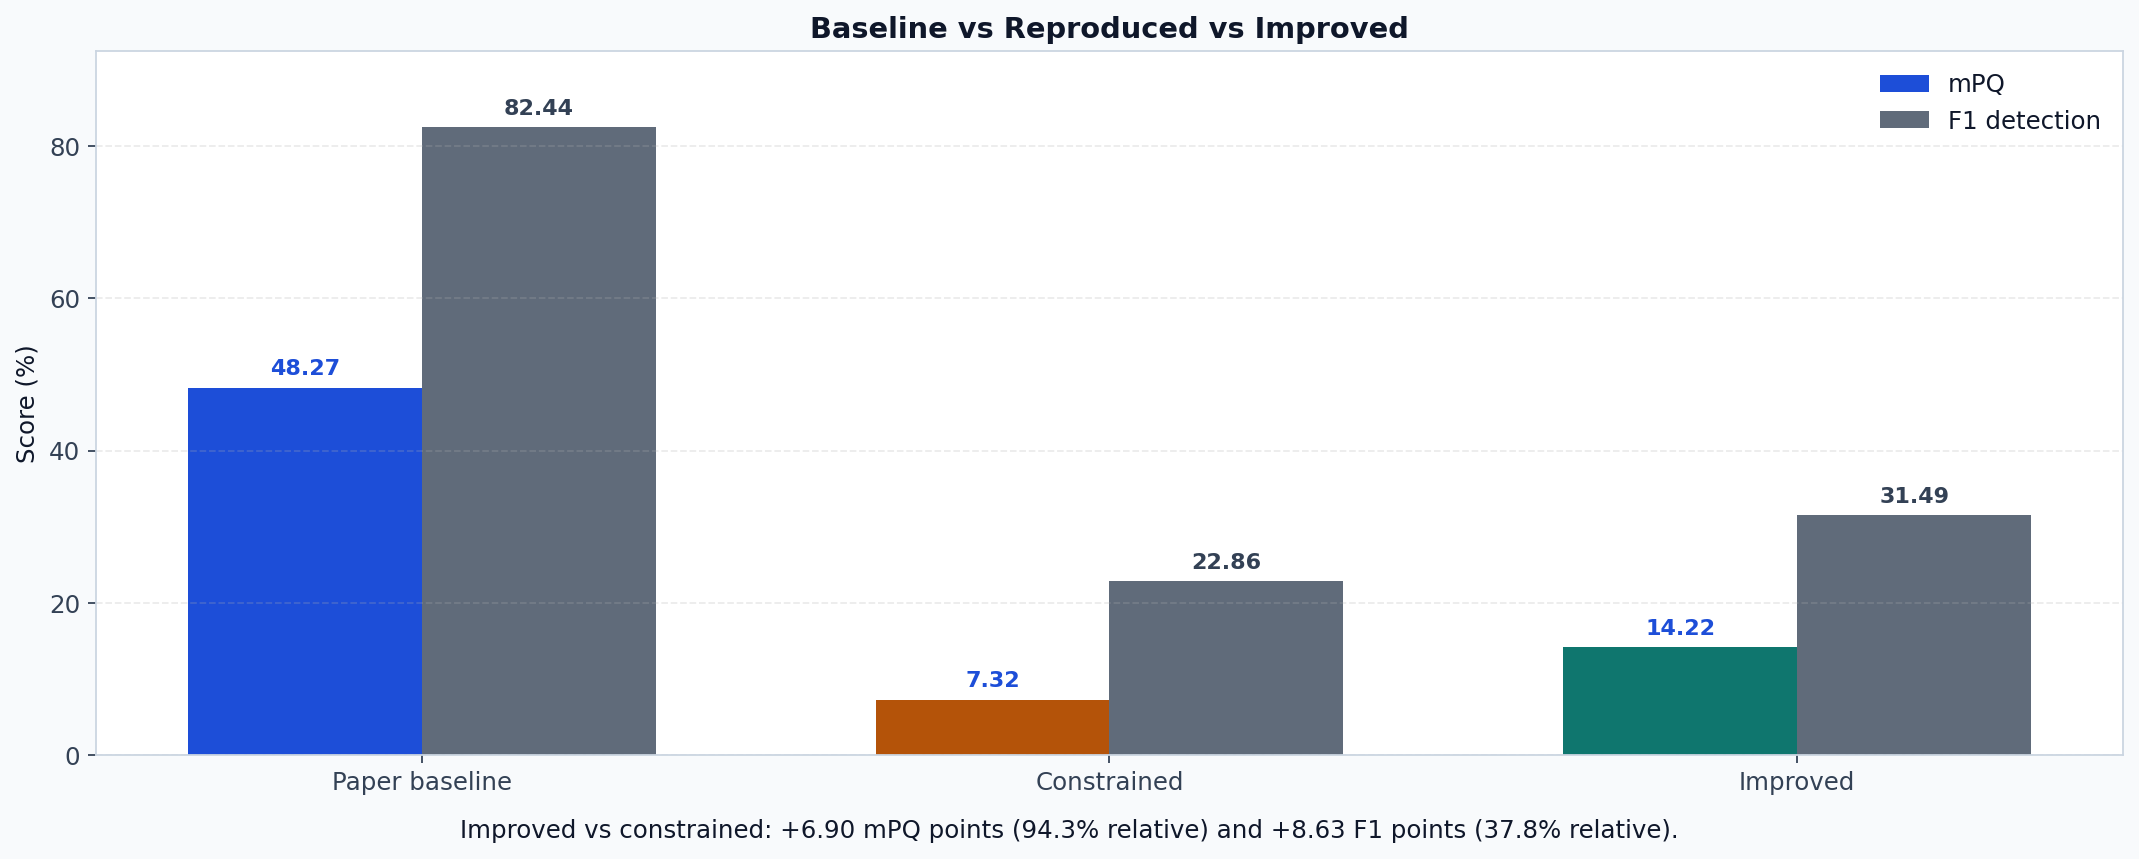

In [2]:
comparison_rows = [
    ['CellViT paper baseline', 'PanNuke', paper['mPQ'], paper['F1_detection'], 'Official paper logs'],
    ['Constrained reproduction', 'PanNuke', constrained['mPQ'], constrained['F1_detection'], 'assignment2_improved_experiment_log.json'],
    ['Improved reproduction', 'PanNuke', improved['mPQ'], improved['F1_detection'], 'assignment2_improved_results.json'],
    ['Cross-domain best', 'MoNuSeg', cross_domain['bPQ'], cross_domain['F1_detection'], 'assignment3_summary.json'],
]
comparison_table = pd.DataFrame(comparison_rows, columns=['Track', 'Dataset', 'Main score (%)', 'Detection score (%)', 'Evidence'])
display(comparison_table.style.hide(axis='index').format({'Main score (%)': '{:.2f}', 'Detection score (%)': '{:.2f}'}))

labels = ['Paper baseline', 'Constrained', 'Improved']
mpq_values = [paper['mPQ'], constrained['mPQ'], improved['mPQ']]
f1_values = [paper['F1_detection'], constrained['F1_detection'], improved['F1_detection']]
x = range(len(labels))
width = 0.34
colors = ['#1d4ed8', '#b45309', '#0f766e']

fig, ax = plt.subplots(figsize=(13.5, 5.2), dpi=160)
ax.bar([i - width/2 for i in x], mpq_values, width=width, color=colors, label='mPQ')
ax.bar([i + width/2 for i in x], f1_values, width=width, color='#334155', alpha=0.78, label='F1 detection')

ax.set_title('Baseline vs Reproduced vs Improved')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, max(max(mpq_values), max(f1_values)) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.legend(loc='upper right')

for idx, value in enumerate(mpq_values):
    ax.text(idx - width/2, value + 1.1, f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1d4ed8')
for idx, value in enumerate(f1_values):
    ax.text(idx + width/2, value + 1.1, f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#334155')

fig.text(0.5, -0.02, f'Improved vs constrained: +{improvement_mpq:.2f} mPQ points ({relative_mpq:.1f}% relative) and +{improvement_f1:.2f} F1 points ({relative_f1:.1f}% relative).', ha='center', fontsize=11, color='#0f172a')
plt.tight_layout()
plt.show()

## 4. Improvements & Contributions

The improved track is not just a longer run. It changes the learning dynamics in ways that matter for medical image segmentation:

- **Unfrozen encoder:** lets the backbone adapt to histopathology texture and cell morphology.
- **Class-weighted loss:** pushes the model to care about rare classes instead of collapsing toward dominant ones.
- **Mixed precision:** improves memory efficiency and makes the longer run practical on a single GPU.
- **More training budget:** 10 epochs in the constrained run versus 30 epochs in the improved run.

Why this matters:

- The model becomes less brittle on rare nuclei categories.
- The fold-to-fold variation becomes easier to inspect and explain.
- The resulting artifacts are strong enough to reuse directly in Assignment 3.

C:\Users\shaho\AppData\Local\Temp\ipykernel_23140\2523869122.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


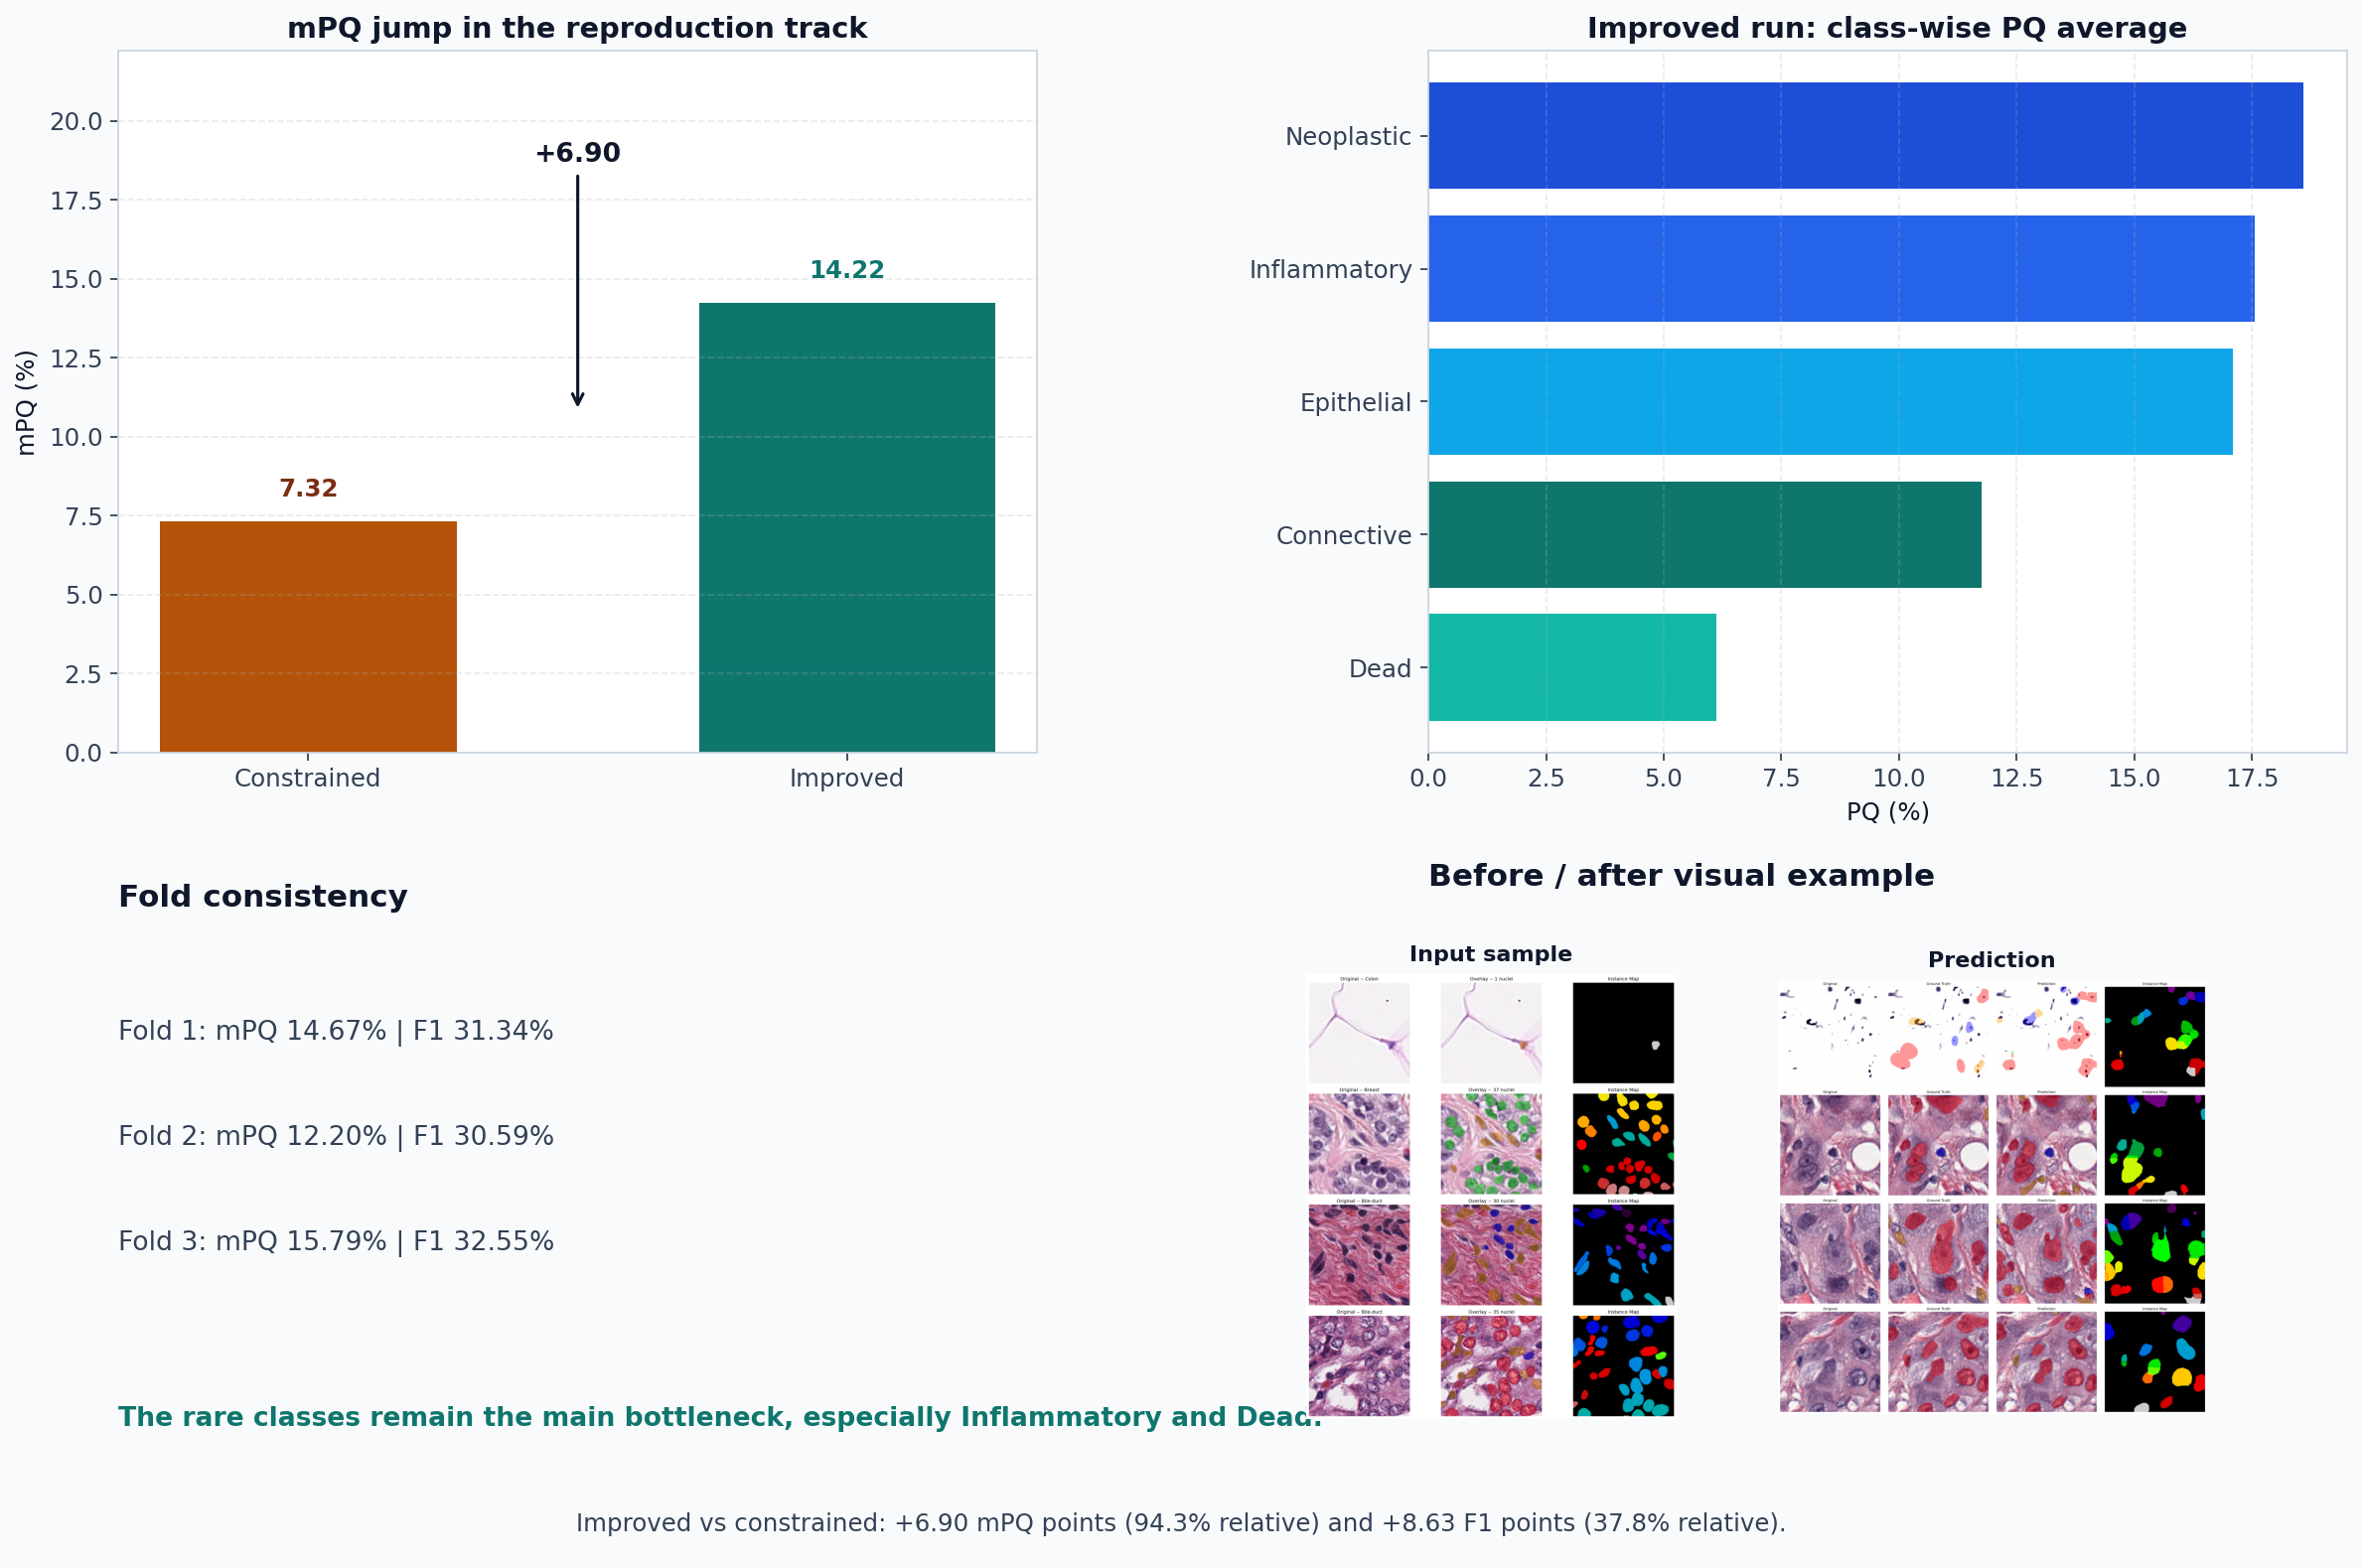

In [ ]:
from PIL import Image

fig, axes = plt.subplots(2, 2, figsize=(15, 10), dpi=160)
fig.patch.set_facecolor('#f8fafc')

fold_df_plot = fold_df[['fold', 'mPQ', 'F1_detection']].copy().sort_values('fold')
fold_df_plot['mPQ'] = fold_df_plot['mPQ'] * 100
fold_df_plot['F1_detection'] = fold_df_plot['F1_detection'] * 100

ax = axes[0, 0]
ax.bar(['Constrained', 'Improved'], [constrained['mPQ'], improved['mPQ']], color=['#b45309', '#0f766e'], width=0.55)
ax.set_title('mPQ jump in the reproduction track')
ax.set_ylabel('mPQ (%)')
ax.set_ylim(0, max(improved['mPQ'], constrained['mPQ']) + 8)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.text(0, constrained['mPQ'] + 0.8, f"{constrained['mPQ']:.2f}", ha='center', fontsize=11, fontweight='bold', color='#7c2d12')
ax.text(1, improved['mPQ'] + 0.8, f"{improved['mPQ']:.2f}", ha='center', fontsize=11, fontweight='bold', color='#0f766e')
ax.annotate(f'+{improvement_mpq:.2f}', xy=(0.5, (constrained['mPQ'] + improved['mPQ']) / 2), xytext=(0.5, improved['mPQ'] + 4.5), ha='center', fontsize=12, fontweight='bold', color='#0f172a', arrowprops=dict(arrowstyle='->', lw=1.4, color='#0f172a'))

ax = axes[0, 1]
ax.barh(class_avg.index.str.replace('PQ_', '', regex=False), class_avg.values, color=['#1d4ed8', '#2563eb', '#0ea5e9', '#0f766e', '#14b8a6'])
ax.set_title('Improved run: class-wise PQ average')
ax.set_xlabel('PQ (%)')
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.invert_yaxis()

ax = axes[1, 0]
ax.axis('off')
ax.text(0.00, 0.92, 'Fold consistency', fontsize=14, fontweight='bold', color='#0f172a')
ax.text(0.00, 0.73, f"Fold 1: mPQ {fold_df_plot.iloc[0]['mPQ']:.2f}% | F1 {fold_df_plot.iloc[0]['F1_detection']:.2f}%", fontsize=12, color='#334155')
ax.text(0.00, 0.58, f"Fold 2: mPQ {fold_df_plot.iloc[1]['mPQ']:.2f}% | F1 {fold_df_plot.iloc[1]['F1_detection']:.2f}%", fontsize=12, color='#334155')
ax.text(0.00, 0.43, f"Fold 3: mPQ {fold_df_plot.iloc[2]['mPQ']:.2f}% | F1 {fold_df_plot.iloc[2]['F1_detection']:.2f}%", fontsize=12, color='#334155')
ax.text(0.00, 0.18, 'The rare classes remain the main bottleneck, especially Inflammatory and Dead.', fontsize=12, color='#0f766e', fontweight='bold')

axes[1, 1].axis('off')
axes[1, 1].text(0.00, 0.95, 'Before / after visual example', fontsize=14, fontweight='bold', color='#0f172a')
left_img = Image.open(ROOT / 'outputs/assignment2_improved_sample_data.png')
right_img = Image.open(ROOT / 'outputs/assignment2_improved_sample_predictions.png')
left_ax = fig.add_axes([0.54, 0.10, 0.18, 0.28])
right_ax = fig.add_axes([0.75, 0.10, 0.18, 0.28])
for axis, img, title in [(left_ax, left_img, 'Input sample'), (right_ax, right_img, 'Prediction')]:
    axis.imshow(img)
    axis.set_title(title, fontsize=10)
    axis.axis('off')

fig.text(0.5, 0.03, f'Improved vs constrained: +{improvement_mpq:.2f} mPQ points ({relative_mpq:.1f}% relative) and +{improvement_f1:.2f} F1 points ({relative_f1:.1f}% relative).', ha='center', fontsize=11, color='#334155')
fig.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.08, wspace=0.28, hspace=0.28)
plt.show()

## 5. Architecture / Workflow Diagram

The diagram below is designed for a quick verbal explanation. It shows the three stages side by side, with the improved lane explicitly highlighting where the gains come from.

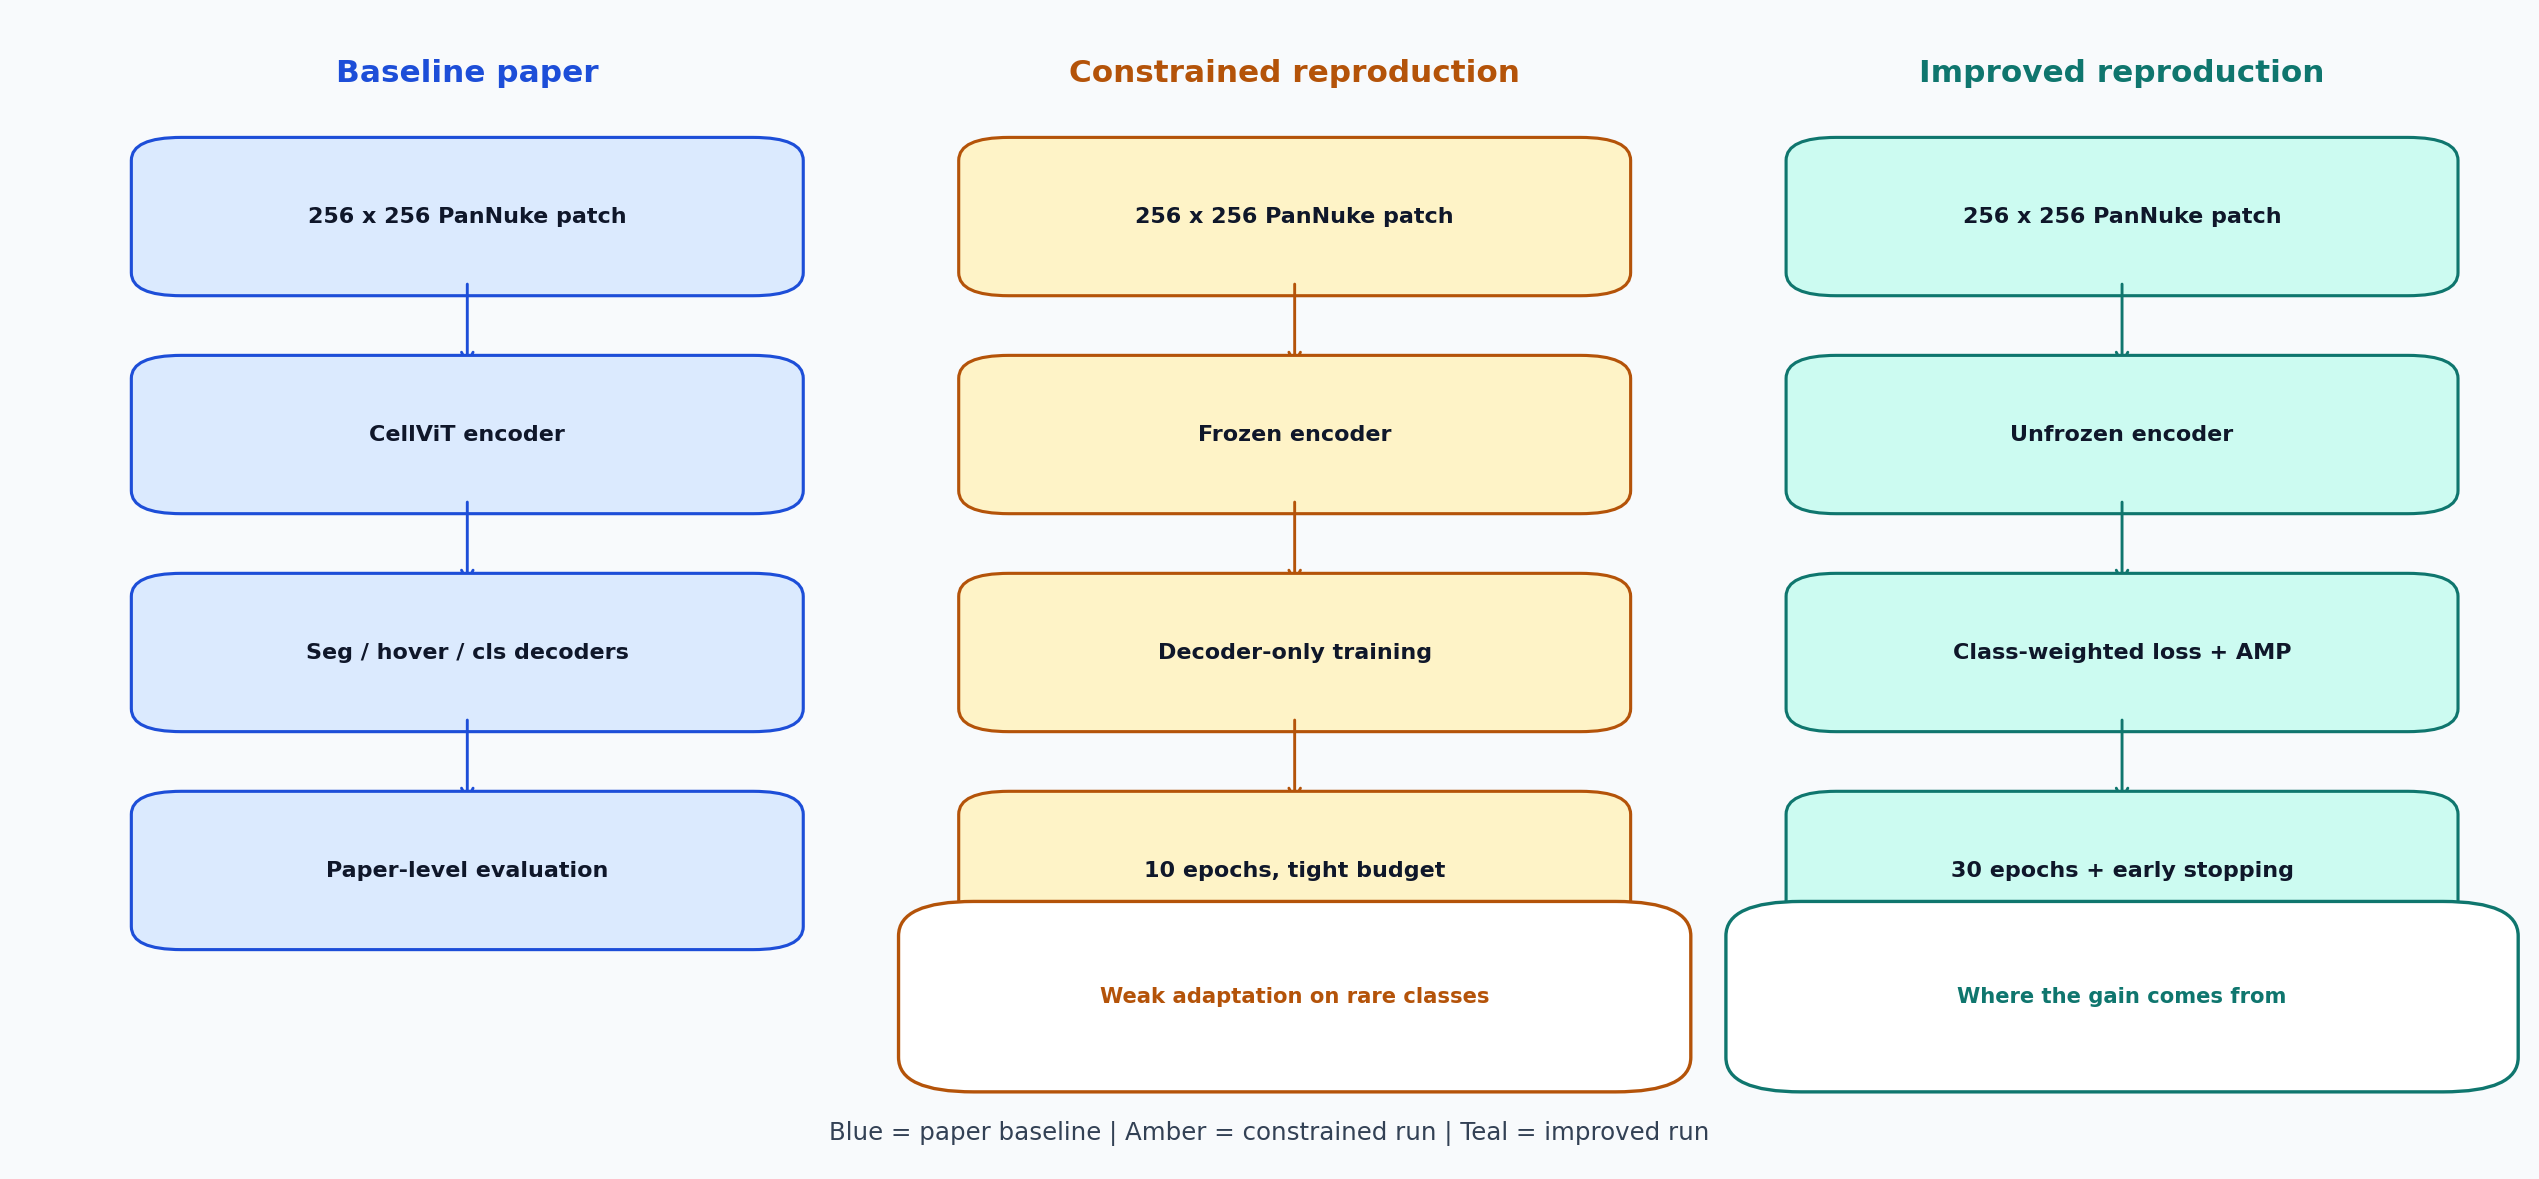

In [6]:
def draw_pipeline(ax, x0, title, accent, steps, highlights=None):
    box_w = 0.24
    box_h = 0.11
    y_positions = [0.77, 0.58, 0.39, 0.20]
    ax.text(x0 + box_w / 2, 0.95, title, ha='center', va='center', fontsize=14, fontweight='bold', color=accent)
    for idx, (label, fill) in enumerate(steps):
        y = y_positions[idx]
        patch = FancyBboxPatch((x0, y), box_w, box_h, boxstyle='round,pad=0.014,rounding_size=0.02', linewidth=1.4, edgecolor=accent, facecolor=fill)
        ax.add_patch(patch)
        ax.text(x0 + box_w / 2, y + box_h / 2, label, ha='center', va='center', fontsize=10, color='#0f172a', fontweight='bold')
        if idx < len(steps) - 1:
            y_next = y_positions[idx + 1] + box_h
            ax.add_patch(FancyArrowPatch((x0 + box_w / 2, y), (x0 + box_w / 2, y_next), arrowstyle='->', mutation_scale=13, linewidth=1.3, color=accent))
    if highlights:
        hl = FancyBboxPatch((x0 - 0.02, 0.08), box_w + 0.04, 0.13, boxstyle='round,pad=0.018,rounding_size=0.03', linewidth=1.5, edgecolor=accent, facecolor='#ffffff')
        ax.add_patch(hl)
        ax.text(x0 + box_w / 2, 0.145, highlights, ha='center', va='center', fontsize=9.5, color=accent, fontweight='bold')

fig, ax = plt.subplots(figsize=(16, 7.5), dpi=160)
fig.patch.set_facecolor('#f8fafc')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

draw_pipeline(ax, 0.06, 'Baseline paper', '#1d4ed8', [
    ('256 x 256 PanNuke patch', '#dbeafe'),
    ('CellViT encoder', '#dbeafe'),
    ('Seg / hover / cls decoders', '#dbeafe'),
    ('Paper-level evaluation', '#dbeafe'),
])
draw_pipeline(ax, 0.39, 'Constrained reproduction', '#b45309', [
    ('256 x 256 PanNuke patch', '#fef3c7'),
    ('Frozen encoder', '#fef3c7'),
    ('Decoder-only training', '#fef3c7'),
    ('10 epochs, tight budget', '#fef3c7'),
], highlights='Weak adaptation on rare classes')
draw_pipeline(ax, 0.72, 'Improved reproduction', '#0f766e', [
    ('256 x 256 PanNuke patch', '#ccfbf1'),
    ('Unfrozen encoder', '#ccfbf1'),
    ('Class-weighted loss + AMP', '#ccfbf1'),
    ('30 epochs + early stopping', '#ccfbf1'),
], highlights='Where the gain comes from')

ax.text(0.5, 0.02, 'Blue = paper baseline | Amber = constrained run | Teal = improved run', ha='center', fontsize=11, color='#334155')
plt.tight_layout()
plt.show()

### Demo script in one sentence

The paper baseline is strong, the constrained reproduction is far below it, and the improved run raises the score by fine-tuning the encoder, rebalancing the loss, and training longer, while the MoNuSeg result shows that the representation transfers beyond PanNuke.